In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
from scalar_autograd import Value
from scalar_autograd.draw import Draw

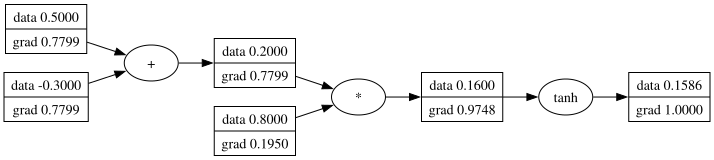

In [3]:
a = Value(0.5)
b = Value(-0.3)
c = a + b
d = Value(0.8)
e = c * d
o = e.tanh()

o.backward()
Draw(o)()

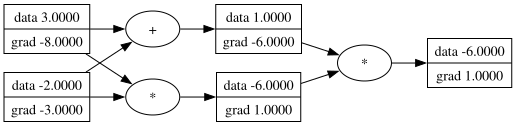

In [4]:
a = Value(-2.0)
b = Value(3.0)
d = a * b
e = a + b
f = d * e

f.backward()
Draw(f)()

In [11]:
from scalar_mlp import MLPtanh

In [14]:
model = MLPtanh(2, [4, 4, 1])

In [6]:
x_train = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
y_train = [1.0, -1.0, -1.0, 1.0]

y_pred = [model(train) for train in x_train]
y_pred

[Value(data=-0.3142, grad=0.0000),
 Value(data=0.1425, grad=0.0000),
 Value(data=-0.3529, grad=0.0000),
 Value(data=-0.3363, grad=0.0000)]

In [20]:
loss = sum((pred - train) ** 2 for train, pred in zip(y_train, y_pred))  # sum of squared errors (SSE)
loss.data

4.144747174152604

In [17]:
model.zero_grad()
loss.backward()

In [18]:
lr = 0.05

for p in m.parameters():
    p.data += -lr * p.grad

---

In [1]:
from scalar_mlp import MLPtanh
from scalar_mlp.loss import sse

from scalar_mlp.trainer import Trainer
from scalar_mlp.lr import constant

In [3]:
x_train = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
y_train = [1.0, -1.0, -1.0, 1.0]

model = MLPtanh(2, [4, 4, 1])
trainer = Trainer(model, sse, x_train, y_train, "karpathy_first_mlp")

(trainer
 .load_parameters()
 .optimize(max_steps=500,
           target_loss=0.1,
           lr=constant(0.04)  # lr of 0.04 seems to be the sweet spot for this model and its size
           )
 .persist_parameters()
 )

no file found at /Users/georg/potential-happiness/_parameters/karpathy_first_mlp.json, skipping
step 0 loss 4.3759
step 1 loss 3.7349
step 2 loss 3.3785
step 3 loss 3.1493
step 4 loss 2.9854
step 5 loss 2.8628
step 6 loss 2.7684
step 7 loss 2.6938
step 8 loss 2.6328
step 9 loss 2.5810
step 10 loss 2.5354
step 11 loss 2.4939
step 12 loss 2.4551
step 13 loss 2.4179
step 14 loss 2.3815
step 15 loss 2.3454
step 16 loss 2.3091
step 17 loss 2.2724
step 18 loss 2.2351
step 19 loss 2.1970
step 20 loss 2.1580
step 21 loss 2.1181
step 22 loss 2.0771
step 23 loss 2.0352
step 24 loss 1.9925
step 25 loss 1.9490
step 26 loss 1.9048
step 27 loss 1.8602
step 28 loss 1.8154
step 29 loss 1.7703
step 30 loss 1.7252
step 31 loss 1.6800
step 32 loss 1.6348
step 33 loss 1.5895
step 34 loss 1.5439
step 35 loss 1.4980
step 36 loss 1.4517
step 37 loss 1.4049
step 38 loss 1.3576
step 39 loss 1.3098
step 40 loss 1.2615
step 41 loss 1.2128
step 42 loss 1.1637
step 43 loss 1.1144
step 44 loss 1.0650
step 45 loss 1